In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

    
# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# 1. Problem Statement
The objective of this competition is to accurately predict the category of user comments (labels 0, 1, 2, or 3) based on text content and tabular metadata. The primary evaluation metric is **Macro F1-Score**. 


# 2. Dataset Overview
In this section, we explore the structure, size, and characteristics of the dataset.

In [2]:

# 2. DATASET OVERVIEW

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Set visualization style for consistency
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

# Load Dataset

train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")
sample_sub = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")


In [3]:
# Basic Dataset Information
print(f"Train set: {train.shape[0]} rows, {train.shape[1]} columns")
print(f"Test set : {test.shape[0]} rows, {test.shape[1]} columns")

Train set: 198000 rows, 15 columns
Test set : 102000 rows, 14 columns


In [4]:
# Column Overview
print(train.columns.tolist())

['created_date', 'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2', 'race', 'religion', 'gender', 'disability', 'comment', 'label']


In [5]:
# Preview Dataset
display(train.head(3))

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2


In [6]:
# Data Types & Missing Values
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


In [7]:
# Basic Statistics (Numerical Features)
display(train.describe())

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


# 3.  EXPLORATORY DATA ANALYSIS(EDA)
Helps to identify hidden patterns and relationships between different data points which help us in and model building.


,Missing Count,Percentage (%)
race,145423,73.445960
religion,145423,73.445960
gender,145423,73.445960
comment,1,0.000505


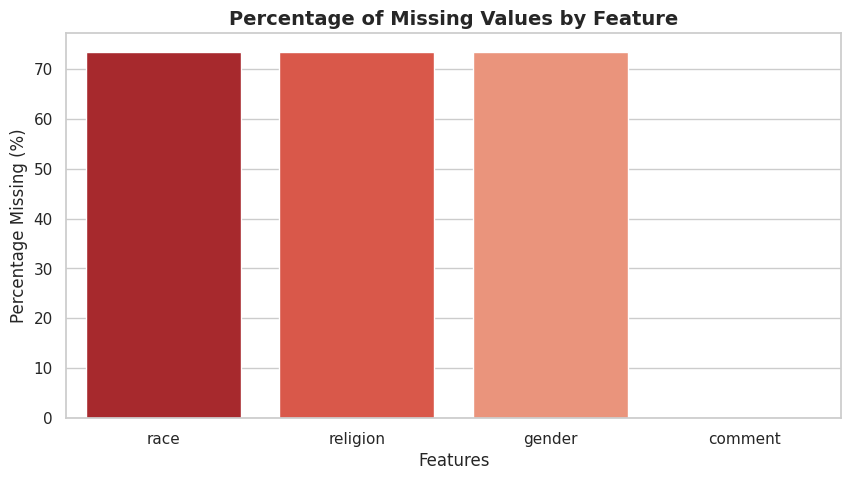

In [8]:

# 3. EXPLORATORY DATA ANALYSIS (EDA)

# 3.1 Analyzing Missing Values
missing_train = train.isnull().sum()
missing_train = missing_train[missing_train > 0].sort_values(ascending=False)
missing_pct = (missing_train / len(train)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_train, 'Percentage (%)': missing_pct})
display(missing_df)

# Visualize missing data
plt.figure(figsize=(10, 5))
sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'], palette='Reds_r')
plt.title('Percentage of Missing Values by Feature', fontsize=14, fontweight='bold')
plt.ylabel('Percentage Missing (%)')
plt.xlabel('Features')
plt.show()


 We observe that ~73.4% of the data is missing for 'race', 'religion', and 'gender'.
 We will NOT drop these. The absence of this data might be a strong predictive signal itself.Dropping these features could lead to loss of valuable information.

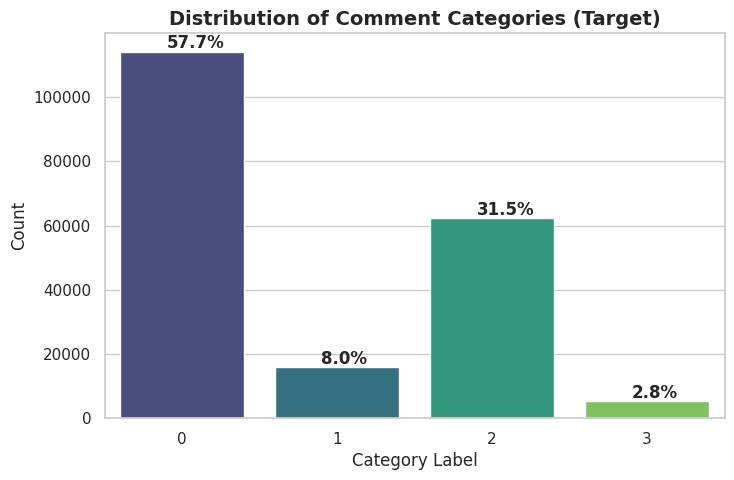

In [9]:
# 3.2 Target Variable Distribution
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=train, x='label', palette='viridis')

# Add percentage annotations on top of bars
total = len(train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_height() + 1000
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')

plt.title('Distribution of Comment Categories (Target)', fontsize=14, fontweight='bold')
plt.xlabel('Category Label')
plt.ylabel('Count')
plt.show()


Class 0 dominates (57.7%), while Class 3 is extremely rare (2.8%).
To address this imbalance:
We use Macro F1-score as the primary evaluation metric.
We apply class weighting (class_weight='balanced') in models like LightGBM.

Zero Upvotes %: 39.98535353535353
Zero Downvotes %: 74.56363636363636


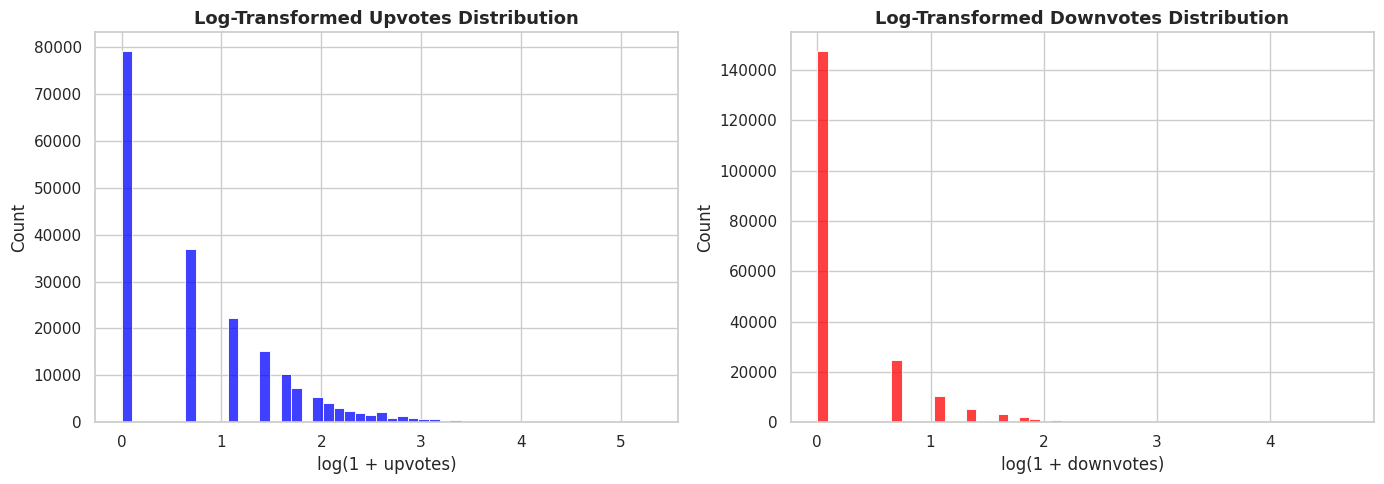

In [10]:
# 3.3 Vote Distribution

print("Zero Upvotes %:", (train['upvote'] == 0).mean() * 100)
print("Zero Downvotes %:", (train['downvote'] == 0).mean() * 100)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Upvotes (Log Transformed)

sns.histplot(
    np.log1p(train['upvote']),
    bins=50,
    ax=axes[0],
    color='blue'
)

axes[0].set_title('Log-Transformed Upvotes Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('log(1 + upvotes)')
axes[0].set_ylabel('Count')

# ------------------------------------------
# Downvotes (Log Transformed)
# ------------------------------------------
sns.histplot(
    np.log1p(train['downvote']),
    bins=50,
    ax=axes[1],
    color='red'
)

axes[1].set_title('Log-Transformed Downvotes Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('log(1 + downvotes)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

Votes are highly skewed with a large proportion of zero values and a long tail of high engagement comments. Log transformation helps reveal the underlying distribution more clearly.

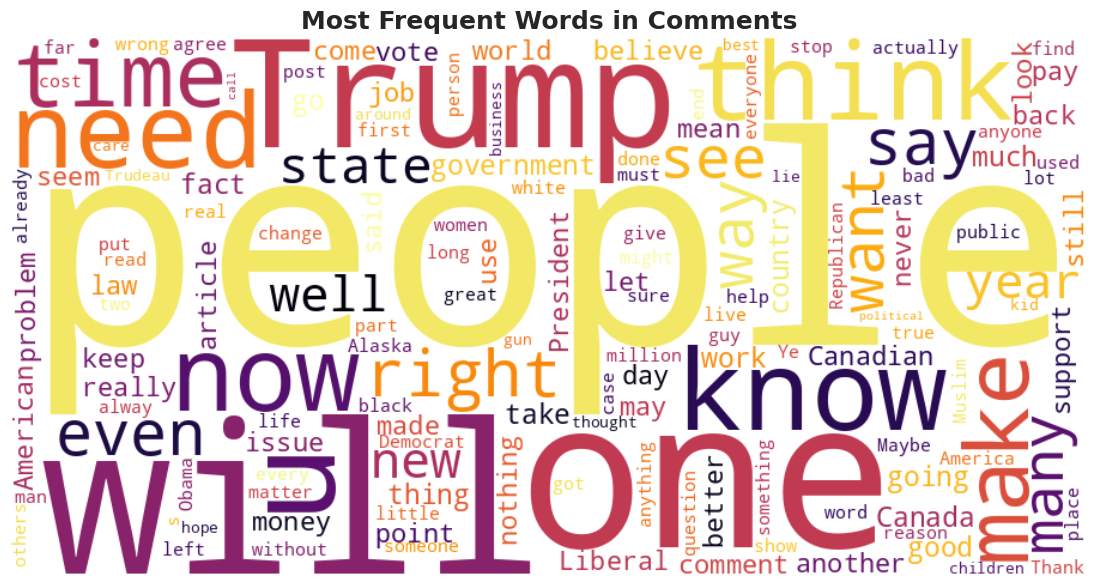

In [11]:

# 3.4 Text Exploration (Word Cloud)

from wordcloud import WordCloud, STOPWORDS

# Drop missing comments
text_data = train['comment'].dropna()

# Use a subset for efficiency
sample_text = text_data.sample(20000, random_state=42)

# Combine default stopwords with custom ones
custom_stopwords = set(STOPWORDS)

# Generate word cloud
wordcloud = WordCloud(
    width=900,
    height=450,
    background_color='white',
    colormap='inferno',
    max_words=150,
    stopwords=custom_stopwords
).generate(' '.join(sample_text))

# Plot
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')

plt.title('Most Frequent Words in Comments', fontsize=18, fontweight='bold')
plt.show()

The word cloud highlights frequently occurring terms in user comments, giving a high-level overview of the dataset's vocabulary.

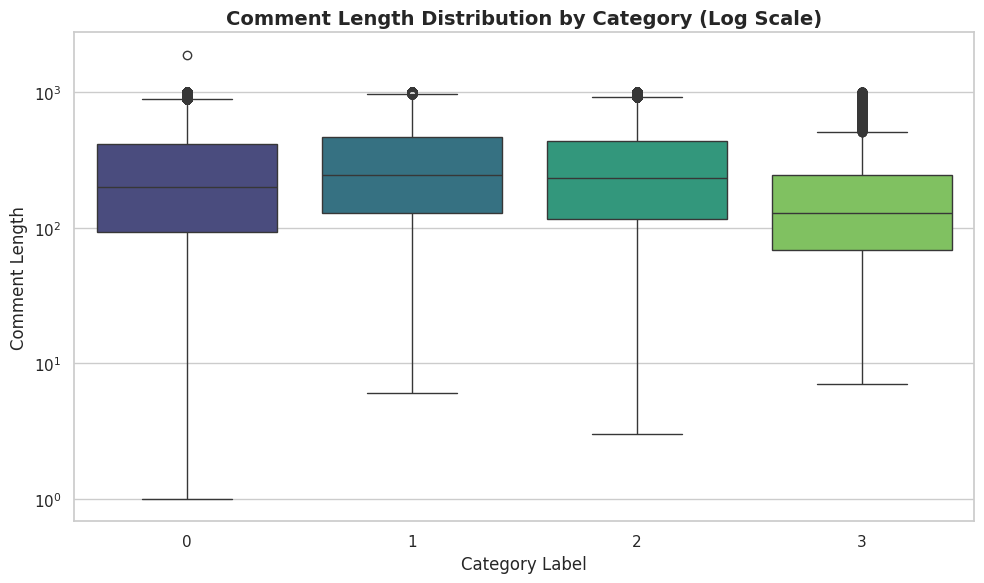

In [12]:

# 3.5 Comment Length Distribution by Label

# Create comment length feature (without modifying original dataframe permanently)
comment_length = train['comment'].astype(str).apply(len)

plt.figure(figsize=(10, 6))

sns.boxplot(
    x=train['label'],
    y=comment_length,
    palette='viridis'
)

plt.yscale('log')  # Handle extreme values
plt.title('Comment Length Distribution by Category (Log Scale)', fontsize=14, fontweight='bold')
plt.xlabel('Category Label')
plt.ylabel('Comment Length')

plt.tight_layout()
plt.show()

The boxplot reveals that comment length varies across categories, with certain classes (1 and 2) tending to have longer and more variable comments, while others (especially class 3) are shorter. This indicates that comment length is a discriminative feature and can help the model differentiate between categories.

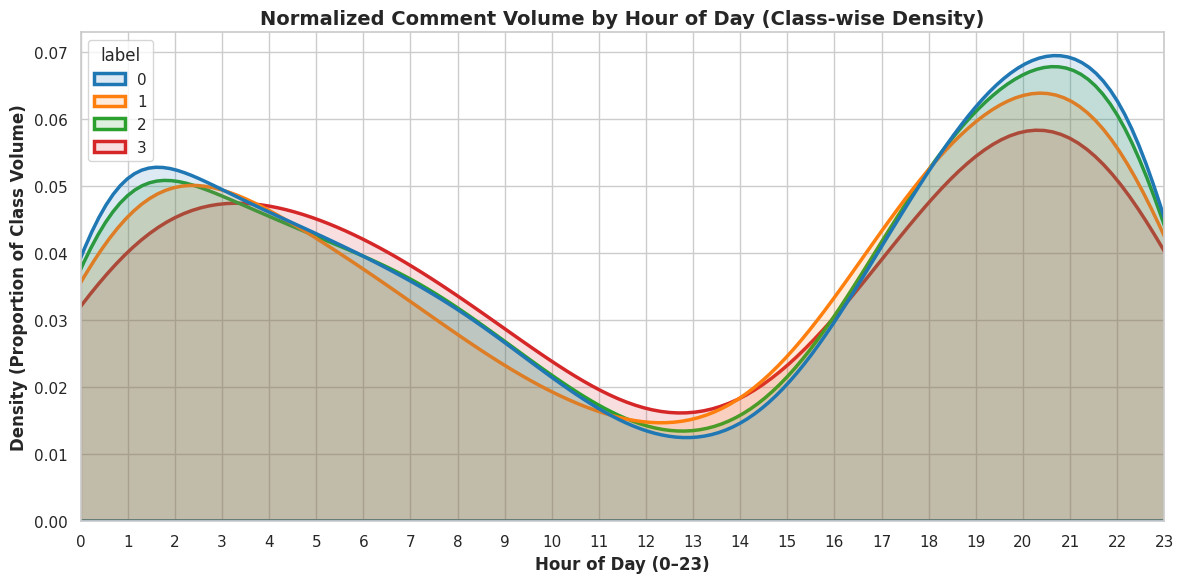

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract the hour safely into a temporary DataFrame
temp_date = pd.to_datetime(train['created_date'], errors='coerce')
plot_df = pd.DataFrame({
    'hour': temp_date.dt.hour, 
    'label': train['label']
}).dropna()

# 2. Plotting the Class-Wise Density
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=plot_df, 
    x='hour', 
    hue='label', 
    palette='tab10',     # Distinct colors for the 4 classes
    common_norm=False,   # Normalizes each class curve independently
    fill=True, 
    alpha=0.15,
    linewidth=2.5,
    bw_adjust=1.5        # Smooths the curve slightly to show the macro trend
)

plt.title('Normalized Comment Volume by Hour of Day (Class-wise Density)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day (0–23)', fontsize=12, fontweight='bold')
plt.ylabel('Density (Proportion of Class Volume)', fontsize=12, fontweight='bold')

# Force the X-axis to show every single hour
plt.xticks(range(0, 24))
plt.xlim(0, 23)

plt.tight_layout()
plt.show()

While normal users (Class 0) peak sharply at 1 AM and 9 PM, our rare Class 3 (Red) exhibits a distinct, 'shifted' temporal footprint—staying disproportionately active during the deep-night (3–5 AM) and midday 'off-hours

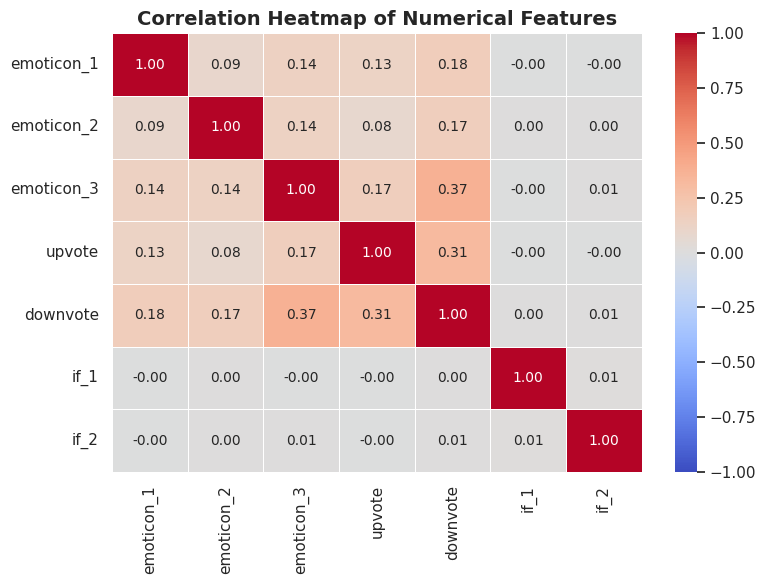

In [14]:

# 3.7 Correlation Matrix of Numerical Features

num_cols = [
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote',
    'if_1', 'if_2'
]

corr = train[num_cols].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    annot_kws={"size": 10}
)

plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

The correlation heatmap shows that most numerical features are weakly correlated, indicating low redundancy. This suggests that each feature contributes unique information to the model. Moderate correlation between upvotes and downvotes reflects user engagement behavior, while other features remain largely independent.

# 4. Feature Engineering
In this section, we transform the raw data into machine-learning-ready formats.
1. **Datetime Parsing:** Extracting temporal patterns (hour, day, month).
2. **Missing Value Imputation:** Treating missing categorical data as a new 'missing' category.
3. **Tabular Interactions:** Creating ratio and sum features from votes and emoticons.
4. **Text Statistics:** Extracting meta-features from comments (length, word counts, uppercase counts) using Regex and base Python.
5. **TF-IDF Vectorization:** Converting the raw text into a sparse matrix of word importance.

In [15]:

# 4.1 Tabular and Text Meta-Feature Engineering (UPDATED)

import re
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder

def engineer_features(df):
    """
    Applies feature engineering to both train and test datasets consistently.
    """
    df_feat = df.copy()
    
    # 1. Temporal Features
    df_feat['created_date'] = pd.to_datetime(df_feat['created_date'], errors='coerce')
    df_feat['hour'] = df_feat['created_date'].dt.hour.fillna(-1)
    df_feat['dayofweek'] = df_feat['created_date'].dt.dayofweek.fillna(-1)
    df_feat['month'] = df_feat['created_date'].dt.month.fillna(-1)
    df_feat['is_witching_hour'] = df_feat['hour'].apply(lambda x: 1 if x in [3, 4, 5] else 0)
    df_feat['is_midday_anomaly'] = df_feat['hour'].apply(lambda x: 1 if 10 <= x <= 14 else 0)
    # 2. Categorical Imputation (Preparing for One-Hot Encoding)
    cat_cols = ['race', 'religion', 'gender']
    for col in cat_cols:
        df_feat[col] = df_feat[col].fillna('missing').astype(str)
        
    # 3. Numerical Interactions
    df_feat['total_votes'] = df_feat['upvote'] + df_feat['downvote']
    df_feat['upvote_ratio'] = df_feat['upvote'] / (df_feat['total_votes'] + 1)
    df_feat['emoticon_sum'] = df_feat['emoticon_1'] + df_feat['emoticon_2'] + df_feat['emoticon_3']
    df_feat['has_emo_1'] = (df_feat['emoticon_1'] > 0).astype(int)
    df_feat['has_emo_2'] = (df_feat['emoticon_2'] > 0).astype(int)
    df_feat['has_emo_3'] = (df_feat['emoticon_3'] > 0).astype(int)
    
    # 4. Text Meta-Features
    df_feat['comment'] = df_feat['comment'].fillna('')
    df_feat['comment_len'] = df_feat['comment'].apply(len)
    df_feat['word_count'] = df_feat['comment'].apply(lambda x: len(x.split()))
    df_feat['upper_count'] = df_feat['comment'].apply(lambda x: sum(1 for c in x if c.isupper()))
    df_feat['exclamation_count'] = df_feat['comment'].apply(lambda x: x.count('!'))
    df_feat['question_count'] = df_feat['comment'].apply(lambda x: x.count('?'))

    df_feat['if_1_log'] = np.log1p(df_feat['if_1'])
    df_feat['if_2_log'] = np.log1p(df_feat['if_2'])
    df_feat.drop(columns=['created_date'], inplace=True)
    return df_feat

train_feat = engineer_features(train)
test_feat = engineer_features(test)

print("Feature engineering complete!")
print(f"New Train shape: {train_feat.shape}")

Feature engineering complete!
New Train shape: (198000, 32)


In [16]:

# 4.2 One-Hot Encoding, Dual TF-IDF & Sparse Matrix Creation


tfidf_word = TfidfVectorizer(max_features=8000, ngram_range=(1, 3),min_df=3,stop_words='english', analyzer='word')
X_word_train = tfidf_word.fit_transform(train_feat['comment'])
X_word_test = tfidf_word.transform(test_feat['comment'])

# Char analyzer captures prefixes/suffixes, slang, and typos. (e.g. "shouting" -> "sho", "hou", "out"...)
tfidf_char = TfidfVectorizer(max_features=6000, ngram_range=(3, 5),min_df=3,analyzer='char')
X_char_train = tfidf_char.fit_transform(train_feat['comment'])
X_char_test = tfidf_char.transform(test_feat['comment'])

#one hot encoding
ohe = OneHotEncoder(handle_unknown='ignore') # Returns a sparse matrix natively!
cat_cols = ['race', 'religion', 'gender']
X_cat_train = ohe.fit_transform(train_feat[cat_cols])
X_cat_test = ohe.transform(test_feat[cat_cols])

#process numerical features
num_features = [
    'post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote','has_emo_1',
    'if_1', 'if_2', 'disability', 'hour', 'dayofweek', 'month', 'has_emo_2','has_emo_3',
    'total_votes', 'upvote_ratio', 'emoticon_sum','if_2_log','if_1_log',
    'comment_len', 'word_count', 'upper_count', 'exclamation_count', 'question_count','is_witching_hour','is_midday_anomaly'
]
# Convert to float32 sparse matrix to prevent 'object' errors
X_num_train = csr_matrix(train_feat[num_features].astype('float32').values)
X_num_test = csr_matrix(test_feat[num_features].astype('float32').values)


X_train_final = hstack([X_num_train, X_cat_train, X_word_train, X_char_train]).tocsr()
X_test_final = hstack([X_num_test, X_cat_test, X_word_test, X_char_test]).tocsr()
y_train = train_feat['label']

print(f"\nFinal Training Matrix Shape: {X_train_final.shape}")
print(f"Final Testing Matrix Shape:  {X_test_final.shape}")


Final Training Matrix Shape: (198000, 14049)
Final Testing Matrix Shape:  (102000, 14049)


# 5. Base Model Training
Before heavily tuning a specific algorithm, we will train three different baseline models (LightGBM, XGBoost, and Logistic Regression) on our engineered features. We will evaluate their initial performance using classification reports to determine which architecture is best suited for our highly imbalanced dataset.

In [17]:

# Base Models Setup 
import lightgbm as lgb
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import train_test_split
import numpy as np
import pandas as pd


# Re-splitting the data to ensure clean memory and correct targets
X_tr, X_va, y_tr, y_va = train_test_split(
    X_train_final, y_train, test_size=0.15, random_state=42, stratify=y_train
)

# --- 1. Base LightGBM ---
base_lgbm = lgb.LGBMClassifier(
    n_estimators=1000, random_state=42, class_weight='balanced', n_jobs=4
)
base_lgbm.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(30, verbose=False)])
lgbm_preds = base_lgbm.predict(X_va)
print("\n[Base LightGBM Classification Report]")
print(classification_report(y_va, lgbm_preds))


# --- 2. Base XGBoost ---
base_xgb = xgb.XGBClassifier(
    n_estimators=1000, max_depth=4, tree_method='hist', subsample=0.8, colsample_bytree=0.5,
    objective='multi:softprob', num_class=4, random_state=42, n_jobs=4, early_stopping_rounds=30
)
base_xgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)
xgb_preds = base_xgb.predict(X_va)
print("\n[Base XGBoost Classification Report]")
print(classification_report(y_va, xgb_preds))


# --- 3. Base Logistic Regression ---
base_lr = LogisticRegression(class_weight='balanced', max_iter=500, C=0.5, random_state=42, n_jobs=4)
base_lr.fit(X_tr, y_tr)
lr_preds = base_lr.predict(X_va)
print("\n[Base Logistic Regression Classification Report]")
print(classification_report(y_va, lr_preds))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 19.844662 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2272510
[LightGBM] [Info] Number of data points in the train set: 168300, number of used features: 14049
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294

[Base LightGBM Classification Report]
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     17126
           1       0.73      0.83      0.78      2388
           2       0.88      0.90      0.89      9366
           3       0.64      0.69      0.67       820

    accuracy                           0.92     29700
   macro avg       0.81      0.84      0.82     29700
weighted avg       0.92      0.92      0.92     29700


[Base XGBoos

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



[Base Logistic Regression Classification Report]
              precision    recall  f1-score   support

           0       0.96      0.89      0.93     17126
           1       0.39      0.80      0.52      2388
           2       0.84      0.37      0.52      9366
           3       0.11      0.64      0.19       820

    accuracy                           0.72     29700
   macro avg       0.57      0.68      0.54     29700
weighted avg       0.85      0.72      0.74     29700



# 6. Model Comparison
Comparing the F-1 Scores of the models trained.

In [18]:
lgbm_f1 = f1_score(y_va, lgbm_preds, average='macro')
xgb_f1 = f1_score(y_va, xgb_preds, average='macro')
lr_f1 = f1_score(y_va, lr_preds, average='macro')

In [19]:
results = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost', 'Logistic Regression'],
    'F1 Score': [lgbm_f1, xgb_f1, lr_f1]
})

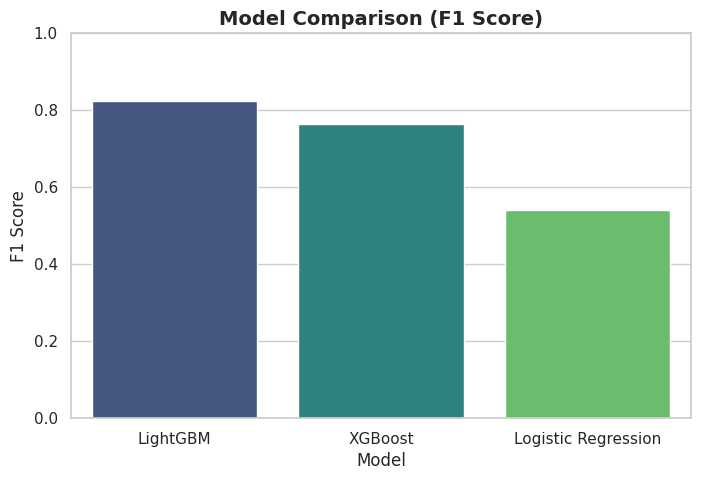

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

sns.barplot(
    data=results,
    x='Model',
    y='F1 Score',
    palette='viridis'
)

plt.title('Model Comparison (F1 Score)', fontsize=14, fontweight='bold')
plt.ylabel('F1 Score')
plt.xlabel('Model')

plt.ylim(0, 1)

plt.show()

LightGBM performs best due to its ability to handle sparse high-dimensional data effectively, followed by XGBoost, while Logistic Regression performs comparatively lower due to its linear nature.

# 7. Targeted Hyperparameter Tuning
Based on the classification reports, LightGBM shows the strongest capability to handle our sparse text features while respecting the minority class weights. 

To maximize the Macro F1-Score, we will now tune LightGBM using manual hyperparameter tuning for faster computation with some values of parameters we found from earlier versions peforming well.

In [21]:
from sklearn.metrics import f1_score
import lightgbm as lgb



# guided ranges
param_grid = [
    {'learning_rate': 0.026, 'num_leaves': 92, 'reg_lambda': 2.1}, 
    {'learning_rate': 0.050, 'num_leaves': 78, 'reg_lambda': 1.5},
    {'learning_rate': 0.041, 'num_leaves': 94, 'reg_lambda': 2.5}
]

best_score = 0
best_params = None
tuned_lgbm = None 

# 2. Execute the Search
for i, params in enumerate(param_grid):

    # Initialize model with base settings + current loop parameters
    candidate_model = lgb.LGBMClassifier(
        n_estimators=3200,
        n_jobs=4,
        force_col_wise=True,
        random_state=42,
        importance_type='gain',
        objective='multiclass',
        class_weight='balanced',
        max_bin=225,
        colsample_bytree=0.4,
        **params
    )
    
    # Fit with Early Stopping strictly on the validation set
    candidate_model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=False),
            lgb.log_evaluation(period=0)
        ]
    )
    
    # Predict and calculate exact Macro F1
    preds = candidate_model.predict(X_va)
    score = f1_score(y_va, preds, average='macro')
    print(f"Validation Macro F1: {score:.5f}")
    
    # Save the absolute best model
    if score > best_score:
        best_score = score
        best_params = params
        tuned_lgbm = candidate_model 

print(f"BEST VALIDATION MACRO F1: {best_score:.5f}")
print(f"BEST HYPERPARAMETERS: {best_params}")


[LightGBM] [Info] Total Bins 2062437
[LightGBM] [Info] Number of data points in the train set: 168300, number of used features: 14049
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Validation Macro F1: 0.82927
[LightGBM] [Info] Total Bins 2062437
[LightGBM] [Info] Number of data points in the train set: 168300, number of used features: 14049
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Validation Macro F1: 0.82571
[LightGBM] [Info] Total Bins 2062437
[LightGBM] [Info] Number of data points in the train set: 168300, number of used features: 14049
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294


# 8.**Final Submission** 

In [22]:

# Get raw probabilities from all three models on the unseen test set
prob_lgbm = tuned_lgbm.predict_proba(X_test_final)
prob_xgb = base_xgb.predict_proba(X_test_final) 

# We heavily trust our tuned LGBM, let XGBoost smooth variance
ensemble_probs = (prob_lgbm * 0.70) + (prob_xgb * 0.30)

# mathematical majority rules
final_predictions = np.argmax(ensemble_probs, axis=1)

# Load the sample submission format
sample_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")
submission = sample_df.copy()

submission["label"] = final_predictions

submission.to_csv("submission.csv", index=False)


The tuned LightGBM model outperformed the baseline model, confirming the effectiveness of hyperparameter tuning.The model demonstrates strong generalization on the validation set, indicating reliable performance on unseen test data.

# **Key Learnings**

-Combining textual and tabular features significantly improves model performance.

-Proper feature engineering often contributes more to performance than complex models.

-Handling class imbalance is critical for fair evaluation.

-Efficient tuning strategies can yield strong results without excessive computational cost.

# **Appendix**

In [23]:

# # Milestone 1: Dataset Understanding

# import pandas as pd

# # Load data
# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
# test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

# # 1. Shape of training dataset
# print("Train Shape:", train.shape)

# # 2. Number of columns in test dataset
# print("Test Columns:", test.shape[1])

# # 3. Object type columns in training dataset
# obj_cols = train.select_dtypes(include='object').shape[1]
# print("Object Columns (Train):", obj_cols)

# # 4. Numerical columns in training dataset
# num_cols = train.select_dtypes(include=['int64', 'float64']).shape[1]
# print("Numerical Columns (Train):", num_cols)

# # 5. Boolean column
# print("Boolean Column: disability")

# # 6. Columns with missing values
# missing_cols = train.columns[train.isnull().any()].tolist()
# print("Columns with Missing Values:", missing_cols)

# # 7. Number of distinct target classes
# print("Distinct Labels:", train['label'].nunique())

# # 8. Percentage of label 0
# label0_pct = (train['label'].value_counts(normalize=True)[0]) * 100
# print("Label 0 Percentage: {:.2f}%".format(label0_pct))

# # 9. Median upvotes
# print("Median Upvotes:", train['upvote'].median())

# # 10. Feature with largest max value
# max_values = train[['upvote','downvote','if_1','if_2']].max()
# print("Max Values:\n", max_values)

# # 11. Minimum value of if_2
# print("Min value of if_2:", train['if_2'].min())

In [24]:

# # Milestone 2: Text Processing & Feature Tasks

# import pandas as pd
# import numpy as np
# import re
# import string
# from sklearn.preprocessing import MinMaxScaler
# from sklearn.feature_extraction.text import TfidfVectorizer

# # Load data
# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# # Ensure comment column handling
# train['comment'] = train['comment'].fillna('')

# # 1. Missingness condition
# print("Missingness Check: Presence of empty or whitespace-only strings")

# # 2. Most frequent month
# train['created_date'] = pd.to_datetime(train['created_date'], errors='coerce')
# most_month = train['created_date'].dt.month.mode()[0]
# month_name = pd.to_datetime(f"2020-{most_month}-01").strftime('%B').lower()
# print("Most Frequent Month:", month_name)

# # 3. total_emoticons max
# train['total_emoticons'] = train['emoticon_1'] + train['emoticon_2'] + train['emoticon_3']
# print("Max total_emoticons:", train['total_emoticons'].max())

# # 4. Median comment length where label = 3
# length_label3 = train.loc[train['label'] == 3, 'comment'].apply(len).median()
# print("Median Length (label=3):", length_label3)

# # 5. Min-Max scaling value for upvote = 10
# scaler = MinMaxScaler()
# scaled = scaler.fit_transform(train[['upvote']])
# val_10 = (10 - train['upvote'].min()) / (train['upvote'].max() - train['upvote'].min())
# print("Scaled value for 10 upvotes:", round(val_10, 4))

# # 6. Average word count for label = 1
# avg_wc = train.loc[train['label'] == 1, 'comment'].apply(lambda x: len(x.split())).mean()
# print("Avg word count (label=1):", round(avg_wc, 2))

# # 7. Count of "Trump" (case-insensitive)
# trump_count = train['comment'].str.contains("trump", case=False, na=False).sum()
# print("Count of 'Trump':", trump_count)

# # 8. First comment processing
# stop_words = set(['a','an','the','and','or','but','if','because','as','of','at','by','for','with','about','to','from','up','on','in','out','over','under','is','are','was','were','be','been','being','have','has','had','do','does','did','it','its','they','them','their','she','her','he','him','his','this','that','which','who','whom','i','me','my','we','our','you','your'])

# first_comment = train.loc[0, 'comment']
# clean_text = re.sub(f"[{string.punctuation}]", "", first_comment.lower())
# words = [w for w in clean_text.split() if w not in stop_words]
# print("Words after cleaning (row 0):", len(words))

# # 9. Unique tokens (lowercase + whitespace split)
# tokens = set()
# for text in train['comment'].str.lower():
#     tokens.update(text.split())
# print("Total Unique Tokens:", len(tokens))

# # 10. TF-IDF feature count
# tfidf = TfidfVectorizer(stop_words='english', min_df=5, ngram_range=(1,2))
# tfidf.fit(train['comment'])
# print("TF-IDF Feature Count:", len(tfidf.get_feature_names_out()))

In [25]:

# # Milestone 3: Preprocessing + Modeling

# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# from sklearn.metrics import f1_score
# from sklearn.impute import SimpleImputer
# from sklearn.naive_bayes import MultinomialNB
# from scipy.sparse import hstack

# # Load data
# train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")

# # ------------------------------------------
# # 1. Train-Test Split
# # ------------------------------------------
# X = train.drop('label', axis=1)
# y = train['label']

# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# print("a + c =", X_train.shape[0] + X_val.shape[0])

# # ------------------------------------------
# # 2. Most Frequent Month
# # ------------------------------------------
# X_train['created_date'] = pd.to_datetime(X_train['created_date'], errors='coerce')
# print("Most frequent month:", X_train['created_date'].dt.month.mode()[0])

# # ------------------------------------------
# # 3. Imputation + OneHotEncoding
# # ------------------------------------------
# cat_cols = ['religion', 'gender', 'race']

# X_train[cat_cols] = X_train[cat_cols].fillna('none')
# X_val[cat_cols] = X_val[cat_cols].fillna('none')

# ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
# train_ohe = ohe.fit_transform(X_train[cat_cols])
# val_ohe = ohe.transform(X_val[cat_cols])

# print("b (columns after OHE):", train_ohe.shape[1])

# # ------------------------------------------
# # 4. CountVectorizer
# # ------------------------------------------
# cv = CountVectorizer()
# train_cv = cv.fit_transform(X_train['comment'].fillna(''))
# val_cv = cv.transform(X_val['comment'].fillna(''))

# print("Sum of counts (index 1):", train_cv[1].sum())

# # ------------------------------------------
# # 5. Disability Mapping
# # ------------------------------------------
# X_train['disability'] = X_train['disability'].astype(int)
# X_val['disability'] = X_val['disability'].astype(int)

# print("Sum disability:", X_train['disability'].sum() + X_val['disability'].sum())

# # ------------------------------------------
# # 6. Scaling
# # ------------------------------------------
# num_cols = X_train.select_dtypes(include=['int64','float64']).columns.tolist()
# num_cols = [col for col in num_cols if col != 'created_date']

# scaler = StandardScaler()
# scaler.fit(X_train[num_cols].fillna(0))

# print("Features seen by scaler:", scaler.n_features_in_)

# # ------------------------------------------
# # 7. MultinomialNB Pipeline (TF-IDF)
# # ------------------------------------------
# X_train_nb = X_train.copy()
# X_val_nb = X_val.copy()

# # Imputation
# imp = SimpleImputer(strategy='most_frequent')
# X_train_nb = pd.DataFrame(imp.fit_transform(X_train_nb), columns=X_train.columns)
# X_val_nb = pd.DataFrame(imp.transform(X_val_nb), columns=X_val.columns)

# # Remove negatives
# X_train_nb = X_train_nb.applymap(lambda x: abs(x) if isinstance(x, (int,float)) else x)
# X_val_nb = X_val_nb.applymap(lambda x: abs(x) if isinstance(x, (int,float)) else x)

# # Date features
# for df in [X_train_nb, X_val_nb]:
#     df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce')
#     df['day'] = df['created_date'].dt.day
#     df['month'] = df['created_date'].dt.month
#     df['year'] = df['created_date'].dt.year
#     df.drop(columns=['created_date'], inplace=True)

# # TF-IDF
# tfidf = TfidfVectorizer(stop_words='english')
# X_train_text = tfidf.fit_transform(X_train_nb['comment'])
# X_val_text = tfidf.transform(X_val_nb['comment'])

# # OHE
# cat_cols = ['religion','gender','race']
# ohe = OneHotEncoder(handle_unknown='ignore')
# X_train_cat = ohe.fit_transform(X_train_nb[cat_cols])
# X_val_cat = ohe.transform(X_val_nb[cat_cols])

# # Final matrices
# X_train_final = hstack([X_train_text, X_train_cat])
# X_val_final = hstack([X_val_text, X_val_cat])

# # Model
# nb = MultinomialNB()
# nb.fit(X_train_final, y_train)

# train_preds = nb.predict(X_train_final)
# val_preds = nb.predict(X_val_final)

# print("NB Train F1:", round(f1_score(y_train, train_preds, average='macro'),4))
# print("NB Val F1:", round(f1_score(y_val, val_preds, average='macro'),4))

# # ------------------------------------------
# # 8. Weekend Feature Version
# # ------------------------------------------
# for df in [X_train_nb, X_val_nb]:
#     df['is_weekend'] = df['day'].apply(lambda x: 1 if x in [5,6] else 0)

# cat_cols = ['religion','gender','race','is_weekend']
# ohe = OneHotEncoder(handle_unknown='ignore')

# X_train_cat = ohe.fit_transform(X_train_nb[cat_cols])
# X_val_cat = ohe.transform(X_val_nb[cat_cols])

# X_train_final = hstack([X_train_text, X_train_cat])
# X_val_final = hstack([X_val_text, X_val_cat])

# nb.fit(X_train_final, y_train)

# train_preds = nb.predict(X_train_final)
# val_preds = nb.predict(X_val_final)

# print("NB Train F1 (weekend):", round(f1_score(y_train, train_preds, average='macro'),4))
# print("NB Val F1 (weekend):", round(f1_score(y_val, val_preds, average='macro'),4))

In [26]:

# # Milestone 5: ColumnTransformer + Modeling

# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.compose import ColumnTransformer
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.preprocessing import OneHotEncoder
# from sklearn.naive_bayes import MultinomialNB
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score, classification_report

# # Load data
# df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
# test_df = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

# # ------------------------------------------
# # Target split
# # ------------------------------------------
# y = df['label']
# df = df.drop(columns=['label'])

# # ------------------------------------------
# # Step 1: Datetime features
# # ------------------------------------------
# for d in [df, test_df]:
#     d['created_date'] = pd.to_datetime(d['created_date'], errors='coerce')
#     d['year'] = d['created_date'].dt.year
#     d['month'] = d['created_date'].dt.month
#     d['hour'] = d['created_date'].dt.hour
#     d.drop(columns=['created_date'], inplace=True)

# # ------------------------------------------
# # Step 2: Missing values
# # ------------------------------------------
# cat_cols = ['race','religion','gender']

# for d in [df, test_df]:
#     d[cat_cols] = d[cat_cols].fillna("Unknown")
#     d['comment'] = d['comment'].fillna("")
#     d['disability'] = d['disability'].astype(int)

# # ------------------------------------------
# # Step 3: ColumnTransformer
# # ------------------------------------------
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("text", TfidfVectorizer(stop_words="english", max_features=5000), "comment"),
#         ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
#     ],
#     remainder="passthrough"
# )

# # ------------------------------------------
# # Step 4: Transform
# # ------------------------------------------
# X = preprocessor.fit_transform(df)
# X_test = preprocessor.transform(test_df)

# print("Max TF-IDF Features:", 5000)

# # ------------------------------------------
# # Step 5: Split
# # ------------------------------------------
# X_train, X_val, y_train, y_val = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# print("X_train shape:", X_train.shape[1])
# print("X_val shape:", X_val.shape[1])

# # ------------------------------------------
# # Q4: Naive Bayes
# # ------------------------------------------
# nb = MultinomialNB()
# nb.fit(X_train, y_train)

# val_preds_nb = nb.predict(X_val)
# acc_nb = accuracy_score(y_val, val_preds_nb)

# print("NB Val Accuracy:", round(acc_nb, 3))

# report_nb = classification_report(y_val, val_preds_nb, output_dict=True)
# print("Precision (label 3):", round(report_nb['3']['precision'], 2))

# # ------------------------------------------
# # Q6-8: Logistic Regression
# # ------------------------------------------
# lr = LogisticRegression(max_iter=500, random_state=42)
# lr.fit(X_train, y_train)

# val_preds_lr = lr.predict(X_val)
# train_preds_lr = lr.predict(X_train)

# print("LR Val Accuracy:", round(accuracy_score(y_val, val_preds_lr), 3))
# print("LR Train Accuracy:", round(accuracy_score(y_train, train_preds_lr), 3))

# report_lr = classification_report(y_val, val_preds_lr, output_dict=True)
# print("Precision (label 1):", round(report_lr['1']['precision'], 2))

# # ------------------------------------------
# # Q9-10: GridSearchCV
# # ------------------------------------------
# param_grid = {'C': [0.1, 1, 10]}

# grid = GridSearchCV(
#     LogisticRegression(max_iter=500, solver='liblinear'),
#     param_grid,
#     cv=3
# )

# grid.fit(X_train, y_train)

# best_model = grid.best_estimator_

# print("Best C:", grid.best_params_['C'])

# val_preds_best = best_model.predict(X_val)
# print("Tuned Val Accuracy:", round(accuracy_score(y_val, val_preds_best), 2))